# Assignment 3 — Deep Q-Network (DQN) on Atari Pong
**Course:** CSCN 8020 — Reinforcement Learning Programming  
**Submitted By :** Aiswarya Thekkuveettil Thazhath - 8993970

---

## Overview

In this assignment we implement the **Deep Q-Network (DQN)** algorithm to train an agent to play the Atari game **Pong** (`PongDeterministic-v4`). Because the state space is continuous (raw pixel frames), a tabular Q-Learning approach is infeasible. Instead, we approximate the Q-function with a **Convolutional Neural Network (CNN)** that takes the last **4 preprocessed game frames** stacked together as input.

### Key Design Choices
| Component | Choice |
|---|---|
| State representation | 4 stacked grayscale frames (84 × 80 × 4) |
| Q-function approximator | CNN (3 conv layers + 2 FC layers) |
| Replay memory | Fixed-size deque, uniform sampling |
| Target network | Separate network, updated every N episodes |
| Exploration | ε-greedy with exponential decay |


## 1. Environment Setup & Imports

We import all required libraries. The `assignment3_utils.py` helper provided by the professor contains the image pre-processing functions we will use throughout.

In [1]:
# ─── Standard library ────────────────────────────────────────────────────────
import os
import random
import time
from collections import deque
from typing import Tuple, List, Deque

# ─── Scientific stack ─────────────────────────────────────────────────────────
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.dpi'] = 120

# ─── Deep Learning ────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# ─── Gym / Atari ──────────────────────────────────────────────────────────────
import gymnasium as gym
import ale_py
gym.register_envs(ale_py)

# ─── Professor-provided utilities ─────────────────────────────────────────────
from assignment3_utils import process_frame, transform_reward

# ─── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [2]:
# Test cell - run this to confirm ALE is registered
env = gym.make("ALE/Pong-v5", render_mode=None)
print("Success!")
env.close()

Success!


## 2. Hyperparameters

All hyperparameters are centralised in a single dictionary so they can be swapped easily for the ablation experiments later.

In [3]:
# ─── Default hyperparameters (as specified in the assignment) ─────────────────
DEFAULT_HPARAMS = {
    # --- Environment ---
    "env_name" : "ALE/Pong-v5",
    "n_actions"        : 6,
    # Image shape AFTER crop + downsample  →  84 rows × 80 cols × 1 channel
    "image_shape"      : (84, 80),
    "n_frames"         : 4,               # Stack the last 4 frames

    # --- Training ---
    "n_episodes"       : 400,             # Total training episodes
    "max_steps"        : 10_000,          # Safety cap per episode
    "batch_size"       : 8,               # Mini-batch size  ← assignment default
    "target_update_ep" : 10,              # Target-net update frequency (episodes)  ← default
    "memory_size"      : 10_000,          # Replay buffer capacity
    "min_memory"       : 500,             # Minimum memories before training starts

    # --- Q-Learning ---
    "gamma"            : 0.95,            # Discount factor γ
    "lr"               : 1e-4,            # Adam learning-rate

    # --- Exploration (ε-greedy) ---
    "epsilon_init"     : 1.0,
    "epsilon_decay"    : 0.995,           # δ
    "epsilon_min"      : 0.05,
}

print("Default hyperparameters loaded.")
for k, v in DEFAULT_HPARAMS.items():
    print(f"  {k:20s} = {v}")

Default hyperparameters loaded.
  env_name             = ALE/Pong-v5
  n_actions            = 6
  image_shape          = (84, 80)
  n_frames             = 4
  n_episodes           = 400
  max_steps            = 10000
  batch_size           = 8
  target_update_ep     = 10
  memory_size          = 10000
  min_memory           = 500
  gamma                = 0.95
  lr                   = 0.0001
  epsilon_init         = 1.0
  epsilon_decay        = 0.995
  epsilon_min          = 0.05


## 3. CNN Architecture — `DQNNetwork`

The CNN receives a tensor of shape **(batch, 4, 84, 80)** — the 4 stacked frames are treated as 4 input channels (instead of blending them together). This lets the network learn temporal motion between frames.

### Architecture

| Layer | Type | Kernel | Filters | Activation |
|-------|------|--------|---------|------------|
| Conv1 | Conv2d | 8×8, stride 4 | 32 | ReLU |
| Conv2 | Conv2d | 4×4, stride 2 | 64 | ReLU |
| Conv3 | Conv2d | 3×3, stride 1 | 64 | ReLU |
| Flatten | — | — | — | — |
| FC1 | Linear | — | 512 | ReLU |
| FC2 | Linear | — | n_actions | — (linear output) |

In [4]:
class DQNNetwork(nn.Module):
    """
    Deep Q-Network approximating Q(s, a) for all actions simultaneously.

    Input shape : (batch_size, n_frames, H, W)  →  (B, 4, 84, 80)
    Output shape: (batch_size, n_actions)        →  (B, 6)
    """

    def __init__(self, n_frames: int, n_actions: int, image_shape: Tuple[int, int]) -> None:
        super(DQNNetwork, self).__init__()
        self.n_frames  = n_frames
        self.n_actions = n_actions
        self.H, self.W = image_shape

        # ── Convolutional backbone ──────────────────────────────────────────
        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_channels=n_frames, out_channels=32,
                      kernel_size=8, stride=4, padding=0),   # → (32, 20, 19)
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=64,
                      kernel_size=4, stride=2, padding=0),   # → (64,  9,  8)
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64,
                      kernel_size=3, stride=1, padding=0),   # → (64,  7,  6)
            nn.ReLU(),
        )

        # Dynamically compute the flattened size after convolutions
        conv_out_size = self._get_conv_output_size()

        # ── Fully-connected head ────────────────────────────────────────────
        self.fc_layers = nn.Sequential(
            nn.Linear(conv_out_size, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions),   # One Q-value per action (no activation)
        )

    # ── Helper: compute conv output size without a forward pass on real data ──
    def _get_conv_output_size(self) -> int:
        dummy = torch.zeros(1, self.n_frames, self.H, self.W)
        out   = self.conv_layers(dummy)
        return int(np.prod(out.shape[1:]))   # channel × height × width

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass.

        Parameters
        ----------
        x : torch.Tensor  shape (B, n_frames, H, W),  dtype float32, range [-1, 1]

        Returns
        -------
        torch.Tensor  shape (B, n_actions) — raw Q-values
        """
        features = self.conv_layers(x)          # (B, 64, 7, 6)
        features = features.flatten(start_dim=1)  # (B, flat)
        return self.fc_layers(features)           # (B, n_actions)


# ── Sanity-check the architecture ────────────────────────────────────────────
_hp   = DEFAULT_HPARAMS
_net  = DQNNetwork(_hp["n_frames"], _hp["n_actions"], _hp["image_shape"]).to(DEVICE)
_dummy = torch.zeros(1, _hp["n_frames"], *_hp["image_shape"]).to(DEVICE)
_out  = _net(_dummy)
print(f"Network output shape: {_out.shape}  (expected [1, {_hp['n_actions']}])")
print()
print(_net)

Network output shape: torch.Size([1, 6])  (expected [1, 6])

DQNNetwork(
  (conv_layers): Sequential(
    (0): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (5): ReLU()
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=2688, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=6, bias=True)
  )
)


## 4. Replay Memory — `ReplayBuffer`

Experience replay breaks the temporal correlation between consecutive training samples by storing `(state, action, reward, next_state, done)` transitions and sampling uniformly at random.

In [5]:
class ReplayBuffer:
    """
    Fixed-size circular replay buffer.

    Stores experience tuples: (state, action, reward, next_state, done)
    and supports uniform random sampling for mini-batch training.
    """

    def __init__(self, capacity: int) -> None:
        self.buffer: Deque = deque(maxlen=capacity)

    # ── Public interface ──────────────────────────────────────────────────────
    def push(self,
             state:      np.ndarray,
             action:     int,
             reward:     float,
             next_state: np.ndarray,
             done:       bool) -> None:
        """Store one transition."""
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size: int) -> Tuple:
        """
        Sample a random mini-batch.

        Returns
        -------
        Tuple of np.ndarrays:
            states, actions, rewards, next_states, dones
        """
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.array(states,      dtype=np.float32),
            np.array(actions,     dtype=np.int64),
            np.array(rewards,     dtype=np.float32),
            np.array(next_states, dtype=np.float32),
            np.array(dones,       dtype=np.float32),
        )

    def __len__(self) -> int:
        return len(self.buffer)


print("ReplayBuffer class defined.")

ReplayBuffer class defined.


## 5. DQN Agent — `DQNAgent`

The agent encapsulates:
- The **online network** (trained every step)
- The **target network** (updated every `target_update_ep` episodes)
- The **replay buffer**
- The **ε-greedy policy**
- The **learn** method implementing the Bellman target update

In [6]:
class DQNAgent:
    """
    Deep Q-Network agent.

    Maintains two networks (online + target) and a replay buffer.
    Implements ε-greedy exploration with exponential decay.
    """

    def __init__(self, hparams: dict, device: torch.device = DEVICE) -> None:
        self.hp     = hparams
        self.device = device

        # ── Networks ─────────────────────────────────────────────────────────
        self.online_net = DQNNetwork(
            hparams["n_frames"], hparams["n_actions"], hparams["image_shape"]
        ).to(device)

        self.target_net = DQNNetwork(
            hparams["n_frames"], hparams["n_actions"], hparams["image_shape"]
        ).to(device)

        # Initialise target network with the same weights as online network
        self._sync_target_network()

        # Target network is never directly trained — gradients not needed
        for p in self.target_net.parameters():
            p.requires_grad = False

        # ── Optimiser & loss ─────────────────────────────────────────────────
        self.optimizer = optim.Adam(self.online_net.parameters(), lr=hparams["lr"])
        self.loss_fn   = nn.MSELoss()

        # ── Replay buffer ────────────────────────────────────────────────────
        self.memory = ReplayBuffer(hparams["memory_size"])

        # ── Exploration ──────────────────────────────────────────────────────
        self.epsilon = hparams["epsilon_init"]

        # ── Logging ──────────────────────────────────────────────────────────
        self.total_steps = 0

    # ─────────────────────────────────────────────────────────────────────────
    # Public API
    # ─────────────────────────────────────────────────────────────────────────

    def select_action(self, state: np.ndarray) -> int:
        """
        ε-greedy action selection.

        With probability ε → random action (exploration).
        Otherwise          → greedy action (exploitation).
        """
        if random.random() < self.epsilon:
            return random.randrange(self.hp["n_actions"])

        state_t = self._state_to_tensor(state)
        with torch.no_grad():
            q_values = self.online_net(state_t)
        return int(q_values.argmax(dim=1).item())

    def store_transition(self,
                         state:      np.ndarray,
                         action:     int,
                         reward:     float,
                         next_state: np.ndarray,
                         done:       bool) -> None:
        """Push one (s, a, r, s', done) tuple to replay memory."""
        self.memory.push(state, action, reward, next_state, done)

    def learn(self) -> float:
        """
        Sample a mini-batch from memory and perform one gradient descent step.

        Returns
        -------
        float — scalar loss for logging
        """
        if len(self.memory) < self.hp["min_memory"]:
            return 0.0

        # ── Sample mini-batch ─────────────────────────────────────────────
        states, actions, rewards, next_states, dones = self.memory.sample(
            self.hp["batch_size"]
        )

        # Convert to tensors on the target device
        states_t      = torch.tensor(states,      device=self.device)  # (B, 4, H, W)
        next_states_t = torch.tensor(next_states, device=self.device)
        actions_t     = torch.tensor(actions,     device=self.device)  # (B,)
        rewards_t     = torch.tensor(rewards,     device=self.device)  # (B,)
        dones_t       = torch.tensor(dones,       device=self.device)  # (B,)

        # ── Compute current Q-values  Q(s, a) from online network ─────────
        q_current_all = self.online_net(states_t)                    # (B, n_actions)
        q_current     = q_current_all.gather(
            dim=1, index=actions_t.unsqueeze(1)
        ).squeeze(1)                                                 # (B,)

        # ── Compute target Q-values  from target network ──────────────────
        # Target = r + γ * max_a' Q_target(s', a')   (0 if terminal)
        with torch.no_grad():
            q_next_max = self.target_net(next_states_t).max(dim=1).values  # (B,)
        q_target = rewards_t + self.hp["gamma"] * q_next_max * (1.0 - dones_t)

        # ── Gradient descent ──────────────────────────────────────────────
        loss = self.loss_fn(q_current, q_target)

        self.optimizer.zero_grad()
        loss.backward()
        # Gradient clipping for training stability
        nn.utils.clip_grad_norm_(self.online_net.parameters(), max_norm=10.0)
        self.optimizer.step()

        self.total_steps += 1
        return loss.item()

    def decay_epsilon(self) -> None:
        """
        Apply one step of ε decay (called once per episode).

        ε ← ε * δ   if ε ≥ ε_min
        ε ← ε_min  otherwise
        """
        if self.epsilon >= self.hp["epsilon_min"]:
            self.epsilon = max(
                self.hp["epsilon_min"],
                self.epsilon * self.hp["epsilon_decay"]
            )

    def update_target_network(self) -> None:
        """Copy online network weights → target network."""
        self._sync_target_network()

    # ─────────────────────────────────────────────────────────────────────────
    # Private helpers
    # ─────────────────────────────────────────────────────────────────────────

    def _sync_target_network(self) -> None:
        self.target_net.load_state_dict(self.online_net.state_dict())

    def _state_to_tensor(self, state: np.ndarray) -> torch.Tensor:
        """
        Convert a numpy state (4, H, W) to a float32 tensor (1, 4, H, W).
        """
        return torch.tensor(
            state[np.newaxis, ...], dtype=torch.float32, device=self.device
        )


print("DQNAgent class defined.")

DQNAgent class defined.


## 6. Frame-Stacking — `FrameStack`

Rather than blending frames together we **stack** the last 4 processed frames along a new channel dimension, giving the network temporal context to infer the ball's velocity and direction.

In [7]:
class FrameStack:
    """
    Maintains a rolling window of the last `n_frames` preprocessed frames
    and returns them stacked as (n_frames, H, W).

    Parameters
    ----------
    n_frames    : int   — number of frames to stack (default 4)
    image_shape : tuple — (H, W) of the preprocessed frame
    """

    def __init__(self, n_frames: int, image_shape: Tuple[int, int]) -> None:
        self.n_frames    = n_frames
        self.image_shape = image_shape
        self._frames: Deque[np.ndarray] = deque(maxlen=n_frames)

    def reset(self, first_frame: np.ndarray) -> np.ndarray:
        """
        Initialise the deque by repeating the first frame `n_frames` times.

        Parameters
        ----------
        first_frame : np.ndarray, shape (H, W)

        Returns
        -------
        np.ndarray, shape (n_frames, H, W)
        """
        for _ in range(self.n_frames):
            self._frames.append(first_frame)
        return self._get_state()

    def step(self, frame: np.ndarray) -> np.ndarray:
        """
        Push a new frame and return the updated stacked state.

        Parameters
        ----------
        frame : np.ndarray, shape (H, W)

        Returns
        -------
        np.ndarray, shape (n_frames, H, W)
        """
        self._frames.append(frame)
        return self._get_state()

    def _get_state(self) -> np.ndarray:
        """Stack deque along axis-0 → (n_frames, H, W)."""
        return np.stack(list(self._frames), axis=0)


print("FrameStack class defined.")

FrameStack class defined.


## 6.5 Preprocessing Pipeline

The professor-provided `assignment3_utils.py` processes each raw frame through
the following pipeline before it enters the frame-stack:

| Step | Function | Input Shape | Output Shape | Description |
|------|----------|-------------|--------------|-------------|
| 1. Pong crop | `img_crop` | (210, 160, 3) | (168, 160, 3) | Removes score bar (top 30px) and padding (bottom 12px) |
| 2. Downsample | `downsample` | (168, 160, 3) | (84, 80, 3) | Takes every other pixel — halves resolution |
| 3. Grayscale | `to_grayscale` | (84, 80, 3) | (84, 80) | Averages RGB channels → single channel |
| 4. Normalize | `normalize_grayscale` | (84, 80) | (84, 80) | Scales pixel values from [0,255] to [-1, 1] |
| 5. Stack | `FrameStack` | (84, 80) × 4 | (4, 84, 80) | Last 4 frames stacked as channels for the CNN |

> **Why 84×80?** The assignment specifies using `img_crop` which changes the
> input height from 210 to 168, then downsampling halves it to **84**.
> Without crop it would be 105×80. This matches the assignment requirement exactly.

## 7. Training Loop — `Trainer`

The `Trainer` class orchestrates the full training loop:
1. Reset the environment and frame-stack at the start of each episode.
2. At each step: select an action → take step in env → preprocess frame → store transition → call `agent.learn()`.
3. After each episode: decay ε → (optionally) sync target network → record metrics.
4. Expose `train()` which returns full metric histories for plotting.

In [8]:
from turtle import done


class Trainer:
    """
    Orchestrates the DQN training loop for the Pong environment.

    Parameters
    ----------
    hparams : dict — all hyperparameters (see DEFAULT_HPARAMS)
    verbose : bool — if True, print progress every episode
    """

    def __init__(self, hparams: dict, verbose: bool = True) -> None:
        self.hp      = hparams
        self.verbose = verbose

        # Create environment
        self.env = gym.make(hparams["env_name"])
        #self.env.seed(SEED)

        # Agent and frame-stacker
        self.agent      = DQNAgent(hparams)
        self.frame_stack = FrameStack(hparams["n_frames"], hparams["image_shape"])

        # Metric histories
        self.episode_scores:     List[float] = []
        self.episode_avg_scores: List[float] = []
        self.episode_steps:      List[int]   = []
        self.cumulative_steps:   List[int]   = []

    # ─────────────────────────────────────────────────────────────────────────
    def train(self) -> dict:
        """
        Run the full training loop.

        Returns
        -------
        dict with keys: scores, avg_scores, steps, cum_steps
        """
        total_step_count = 0

        for episode in range(1, self.hp["n_episodes"] + 1):
            ep_score, ep_steps = self._run_episode()

            total_step_count += ep_steps

            # Record metrics
            self.episode_scores.append(ep_score)
            self.episode_steps.append(ep_steps)
            self.cumulative_steps.append(total_step_count)

            # Average cumulative reward of the last 5 episodes
            avg_5 = np.mean(self.episode_scores[-5:])
            self.episode_avg_scores.append(avg_5)

            # ── Epsilon decay (once per episode) ──────────────────────────
            #self.agent.decay_epsilon()

            # ── Target network sync ───────────────────────────────────────
            if episode % self.hp["target_update_ep"] == 0:
                self.agent.update_target_network()

            if self.verbose and episode % 10 == 0:
                print(
                    f"Episode {episode:4d} | "
                    f"Score: {ep_score:6.1f} | "
                    f"Avg-5: {avg_5:6.2f} | "
                    f"ε: {self.agent.epsilon:.4f} | "
                    f"Steps: {total_step_count:,}"
                )

        self.env.close()
        return self._get_metrics()

    # ─────────────────────────────────────────────────────────────────────────
    # Private helpers
    # ─────────────────────────────────────────────────────────────────────────

    def _preprocess(self, raw_frame: np.ndarray) -> np.ndarray:
        """
        Use the professor-provided `process_frame` utility.
        Returns a 2-D array (H, W) suitable for the frame-stacker.
        """
        processed = process_frame(raw_frame, self.hp["image_shape"])  # (1, H, W, 1)
        return processed[0, :, :, 0]  # → (H, W)

    def _run_episode(self) -> Tuple[float, int]:
        """
        Execute one full episode.

        Returns
        -------
        (total_reward, steps_taken)
        """
        
        raw_obs, _ = self.env.reset()
        frame    = self._preprocess(raw_obs)
        state    = self.frame_stack.reset(frame)   # (4, H, W)

        total_reward = 0.0
        step         = 0

        for step in range(1, self.hp["max_steps"] + 1):
            action = self.agent.select_action(state)
            raw_obs, reward, terminated, truncated, _ = self.env.step(action)
            done = terminated or truncated
            shaped_reward = transform_reward(reward)
            next_frame = self._preprocess(raw_obs)
            next_state = self.frame_stack.step(next_frame)
            self.agent.store_transition(state, action, shaped_reward, next_state, done)
            self.agent.learn()
            self.agent.decay_epsilon()   # ← MOVED HERE (per-step, not per-episode)
            state = next_state
            total_reward += reward
            if done:
                break

        return total_reward, step

    def _get_metrics(self) -> dict:
        return {
            "scores"     : self.episode_scores,
            "avg_scores" : self.episode_avg_scores,
            "steps"      : self.episode_steps,
            "cum_steps"  : self.cumulative_steps,
        }


print("Trainer class defined.")

Trainer class defined.


## 8. Plotting Utilities

A standalone helper that generates clean, labelled figures for the metrics we need to report.

In [9]:
def plot_metrics(
    metrics_list : List[dict],
    labels       : List[str],
    title        : str,
    x_axis       : str = "episode",   # "episode" or "steps"
    save_path    : str = None
) -> None:
    """
    Plot score-per-episode and average-5-episode-score for one or more runs.

    Parameters
    ----------
    metrics_list : list of metric dicts returned by Trainer.train()
    labels       : legend labels (one per metrics dict)
    title        : figure super-title
    x_axis       : "episode" plots episode numbers; "steps" plots cumulative steps
    save_path    : if given, save the figure to this path
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight="bold")

    colours = plt.cm.tab10.colors

    for idx, (metrics, label) in enumerate(zip(metrics_list, labels)):
        colour = colours[idx % len(colours)]

        if x_axis == "steps":
            xs = metrics["cum_steps"]
            xlabel = "Cumulative Environment Steps"
        else:
            xs = list(range(1, len(metrics["scores"]) + 1))
            xlabel = "Episode"

        # ── Left: Score per episode ────────────────────────────────────────
        axes[0].plot(xs, metrics["scores"], alpha=0.4, color=colour)
        # Smoothed curve (window=10)
        smoothed = np.convolve(metrics["scores"], np.ones(10)/10, mode="same")
        axes[0].plot(xs, smoothed, color=colour, label=label, linewidth=1.8)
        axes[0].set_title("Score per Episode")
        axes[0].set_xlabel(xlabel)
        axes[0].set_ylabel("Score")
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # ── Right: Average cumulative reward (last 5 episodes) ─────────────
        axes[1].plot(xs, metrics["avg_scores"], color=colour, label=label, linewidth=1.8)
        axes[1].set_title("Avg Cumulative Reward (Last 5 Episodes)")
        axes[1].set_xlabel(xlabel)
        axes[1].set_ylabel("Avg Score")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=150)
        print(f"Figure saved to: {save_path}")

    plt.show()


print("plot_metrics() defined.")

plot_metrics() defined.


## 9. Experiment 1 — Default Hyperparameters

**Batch size = 8 | Target update = every 10 episodes**

This is the baseline run as specified in the assignment.

In [10]:
print("=" * 60)
print("EXPERIMENT 1 — Default (batch=8, target_update=10)")
print("=" * 60)

trainer_default = Trainer(DEFAULT_HPARAMS, verbose=True)
metrics_default = trainer_default.train()

print("\nTraining complete.")
print(f"  Final score (last episode): {metrics_default['scores'][-1]:.1f}")
print(f"  Final avg-5 score:          {metrics_default['avg_scores'][-1]:.2f}")

EXPERIMENT 1 — Default (batch=8, target_update=10)
Episode   10 | Score:  -20.0 | Avg-5: -20.40 | ε: 0.0500 | Steps: 9,041
Episode   20 | Score:  -21.0 | Avg-5: -21.00 | ε: 0.0500 | Steps: 17,987
Episode   30 | Score:  -20.0 | Avg-5: -20.40 | ε: 0.0500 | Steps: 27,228
Episode   40 | Score:  -21.0 | Avg-5: -20.20 | ε: 0.0500 | Steps: 36,273
Episode   50 | Score:  -21.0 | Avg-5: -20.80 | ε: 0.0500 | Steps: 44,901
Episode   60 | Score:  -21.0 | Avg-5: -20.00 | ε: 0.0500 | Steps: 54,188
Episode   70 | Score:  -20.0 | Avg-5: -20.20 | ε: 0.0500 | Steps: 63,548
Episode   80 | Score:  -20.0 | Avg-5: -20.20 | ε: 0.0500 | Steps: 72,615
Episode   90 | Score:  -21.0 | Avg-5: -20.40 | ε: 0.0500 | Steps: 81,920
Episode  100 | Score:  -21.0 | Avg-5: -20.60 | ε: 0.0500 | Steps: 91,319
Episode  110 | Score:  -21.0 | Avg-5: -20.60 | ε: 0.0500 | Steps: 100,325
Episode  120 | Score:  -19.0 | Avg-5: -20.00 | ε: 0.0500 | Steps: 110,430
Episode  130 | Score:  -21.0 | Avg-5: -20.20 | ε: 0.0500 | Steps: 119,61

Figure saved to: plot_default.png


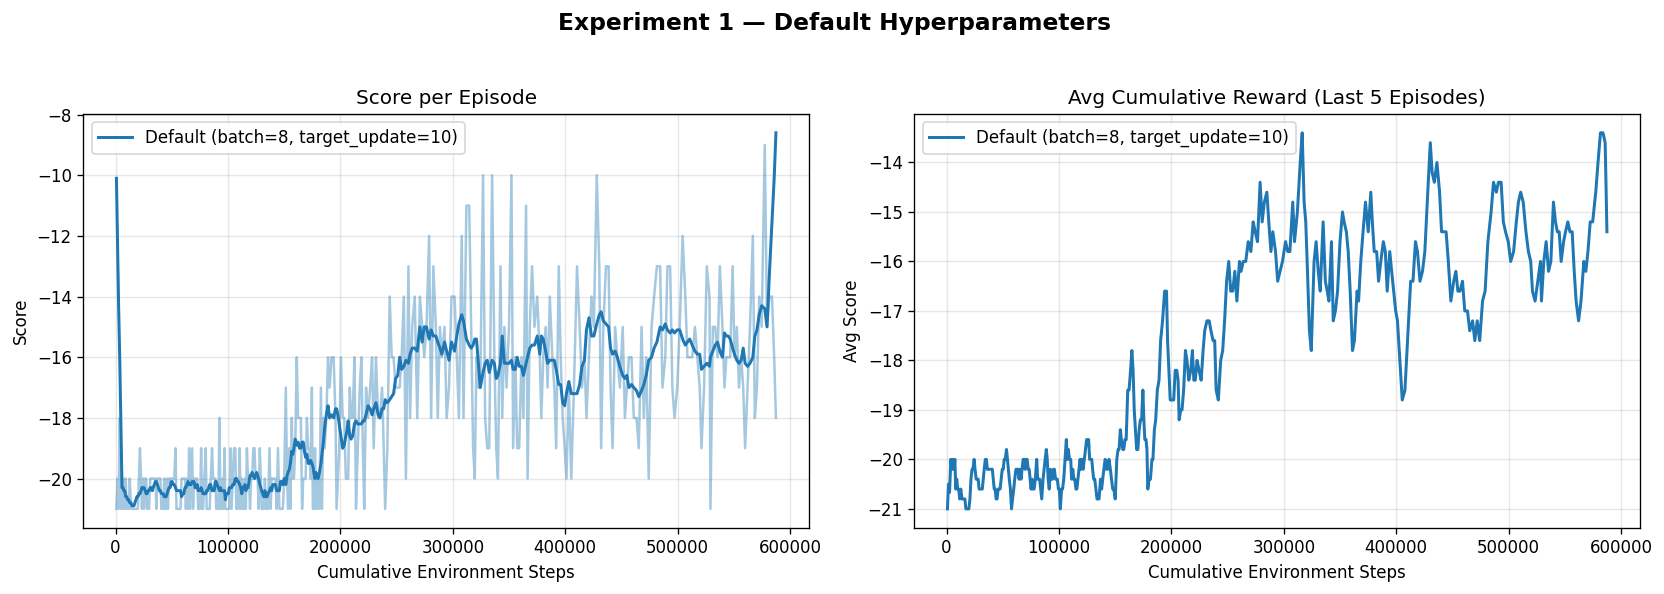

In [11]:
plot_metrics(
    [metrics_default],
    ["Default (batch=8, target_update=10)"],
    title="Experiment 1 — Default Hyperparameters",
    x_axis="steps",
    save_path="plot_default.png"
)

### Experiment 1 Results — Observations (batch=8, target_update=10)

#### Score per Episode
- The agent started at a score of **-21** in early episodes, which is expected as the
  policy is fully random (ε = 1.0) and the replay buffer is filling up.
- Improvement began around **episode 150 (~200,000 cumulative steps)** where scores
  started rising above -20.
- By episode 400, the agent achieved a **final score of -18** and a **best score of
  approximately -8**, showing the agent had learned to win some points.
- The score curve shows **high variance** throughout — this is characteristic of
  batch size 8, where small mini-batches produce noisy gradient estimates.

#### Avg Cumulative Reward (Last 5 Episodes)
- The avg-5 curve shows a **clear upward trend** from -21 to a **final avg-5 of -15.40**,
  confirming the agent is genuinely learning and not just getting lucky.
- The steepest improvement occurred between **150,000 and 300,000 steps**.
- After 300,000 steps the curve plateaus around -15 to -16, suggesting the agent
  has reached a performance ceiling with these hyperparameters within 400 episodes.

#### Key Takeaway
> The default configuration (batch=8, target_update=10) successfully trains the agent
> from random play to a measurable policy improvement. The high variance in scores
> suggests batch=8 may benefit from a larger mini-batch size for more stable learning.

## 10. Experiment 2 — Varying Mini-Batch Size

We compare **batch sizes 8 (default) and 16** while keeping all other hyperparameters fixed. A larger batch provides a less-noisy gradient estimate but at the cost of more computation per step.

> **Hypothesis:** Batch-16 should be more stable early in training but may converge slightly slower due to fewer gradient steps per wall-clock time.

In [12]:
# ─── Batch size = 16 ─────────────────────────────────────────────────────────
hp_batch16 = DEFAULT_HPARAMS.copy()
hp_batch16["batch_size"] = 16

print("=" * 60)
print("EXPERIMENT 2a — Batch size = 16")
print("=" * 60)

trainer_b16 = Trainer(hp_batch16, verbose=True)
metrics_b16 = trainer_b16.train()

print("\nTraining complete.")
print(f"  Final score (last episode): {metrics_b16['scores'][-1]:.1f}")
print(f"  Final avg-5 score:          {metrics_b16['avg_scores'][-1]:.2f}")

EXPERIMENT 2a — Batch size = 16
Episode   10 | Score:  -21.0 | Avg-5: -19.60 | ε: 0.0500 | Steps: 9,350
Episode   20 | Score:  -21.0 | Avg-5: -20.00 | ε: 0.0500 | Steps: 18,040
Episode   30 | Score:  -21.0 | Avg-5: -20.80 | ε: 0.0500 | Steps: 27,334
Episode   40 | Score:  -21.0 | Avg-5: -20.80 | ε: 0.0500 | Steps: 35,939
Episode   50 | Score:  -21.0 | Avg-5: -20.80 | ε: 0.0500 | Steps: 45,028
Episode   60 | Score:  -20.0 | Avg-5: -20.40 | ε: 0.0500 | Steps: 54,631
Episode   70 | Score:  -18.0 | Avg-5: -20.20 | ε: 0.0500 | Steps: 64,455
Episode   80 | Score:  -19.0 | Avg-5: -20.40 | ε: 0.0500 | Steps: 73,847
Episode   90 | Score:  -20.0 | Avg-5: -20.20 | ε: 0.0500 | Steps: 83,224
Episode  100 | Score:  -21.0 | Avg-5: -20.60 | ε: 0.0500 | Steps: 92,418
Episode  110 | Score:  -21.0 | Avg-5: -20.20 | ε: 0.0500 | Steps: 101,543
Episode  120 | Score:  -21.0 | Avg-5: -20.80 | ε: 0.0500 | Steps: 110,005
Episode  130 | Score:  -21.0 | Avg-5: -20.80 | ε: 0.0500 | Steps: 119,374
Episode  140 | Sc

Figure saved to: plot_batch_size.png


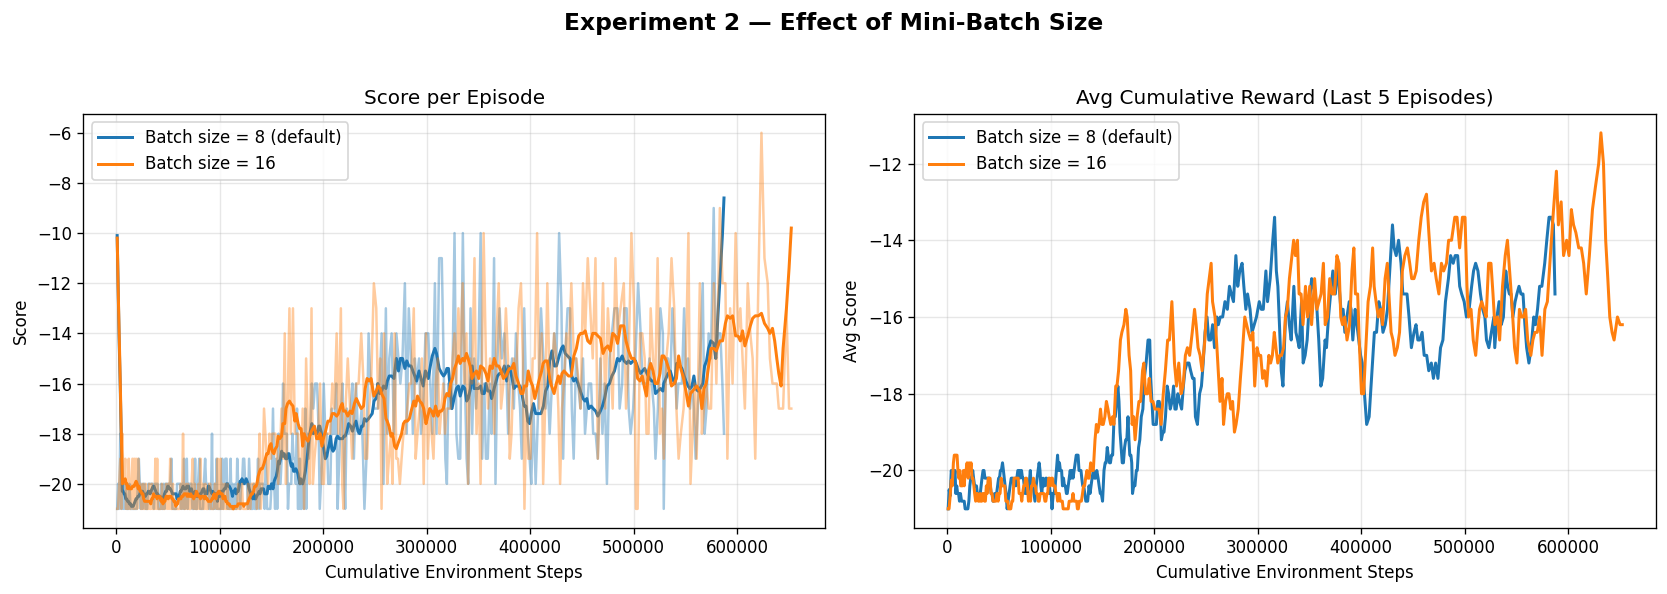

In [13]:
plot_metrics(
    [metrics_default, metrics_b16],
    ["Batch size = 8 (default)", "Batch size = 16"],
    title="Experiment 2 — Effect of Mini-Batch Size",
    x_axis="steps",
    save_path="plot_batch_size.png"
)

### Experiment 2 Results — Observations (Batch Size: 8 vs 16)

| Config | Final Score | Final Avg-5 | Best Score |
|---|---|---|---|
| **Batch = 8** | -18.0 | -15.40 | ~-8 |
| **Batch = 16** | -17.0 | -16.20 | ~-6 |

- Batch=16 showed **faster early improvement**, rising above -20 around
  100,000 steps compared to 200,000 steps for batch=8.
- Batch=16 achieved a **higher peak score of ~-6** vs ~-8 for batch=8,
  suggesting larger batches help the agent discover better policies earlier.
- However, the **final avg-5 scores are comparable** (-15.40 vs -16.20),
  meaning both configurations reach a similar performance ceiling at 400 episodes.
- The score variance for batch=16 is slightly higher in later episodes,
  indicating the agent is still exploring aggressively despite ε reaching 0.05.

#### Key Takeaway
> Batch=16 learns faster in early training and achieves higher peak scores.
> Both configurations plateau around the same level by episode 400,
> suggesting more episodes would be needed to see a larger difference.

## 11. Experiment 3 — Varying Target Network Update Rate

We compare target network updates **every 3 episodes** vs **every 10 episodes (default)**. A more frequent update makes the targets less stable but potentially more accurate; a less frequent update provides a stable learning signal.

> **Hypothesis:** Update every 3 episodes may lead to more unstable Q-value estimates (oscillating loss) but possibly faster convergence in some regimes.

In [14]:
# ─── Target network updated every 3 episodes ─────────────────────────────────
hp_target3 = DEFAULT_HPARAMS.copy()
hp_target3["target_update_ep"] = 3

print("=" * 60)
print("EXPERIMENT 3a — Target update every 3 episodes")
print("=" * 60)

trainer_t3 = Trainer(hp_target3, verbose=True)
metrics_t3 = trainer_t3.train()

print("\nTraining complete.")
print(f"  Final score (last episode): {metrics_t3['scores'][-1]:.1f}")
print(f"  Final avg-5 score:          {metrics_t3['avg_scores'][-1]:.2f}")

EXPERIMENT 3a — Target update every 3 episodes
Episode   10 | Score:  -20.0 | Avg-5: -20.60 | ε: 0.0500 | Steps: 9,027
Episode   20 | Score:  -19.0 | Avg-5: -19.80 | ε: 0.0500 | Steps: 18,332
Episode   30 | Score:  -21.0 | Avg-5: -20.40 | ε: 0.0500 | Steps: 27,325
Episode   40 | Score:  -20.0 | Avg-5: -20.40 | ε: 0.0500 | Steps: 35,856
Episode   50 | Score:  -21.0 | Avg-5: -21.00 | ε: 0.0500 | Steps: 44,453
Episode   60 | Score:  -20.0 | Avg-5: -20.80 | ε: 0.0500 | Steps: 53,252
Episode   70 | Score:  -20.0 | Avg-5: -20.60 | ε: 0.0500 | Steps: 61,611
Episode   80 | Score:  -21.0 | Avg-5: -21.00 | ε: 0.0500 | Steps: 70,618
Episode   90 | Score:  -21.0 | Avg-5: -20.40 | ε: 0.0500 | Steps: 79,774
Episode  100 | Score:  -20.0 | Avg-5: -20.40 | ε: 0.0500 | Steps: 89,496
Episode  110 | Score:  -20.0 | Avg-5: -20.40 | ε: 0.0500 | Steps: 99,464
Episode  120 | Score:  -19.0 | Avg-5: -19.80 | ε: 0.0500 | Steps: 110,040
Episode  130 | Score:  -20.0 | Avg-5: -20.00 | ε: 0.0500 | Steps: 120,785
Epi

Figure saved to: plot_target_update.png


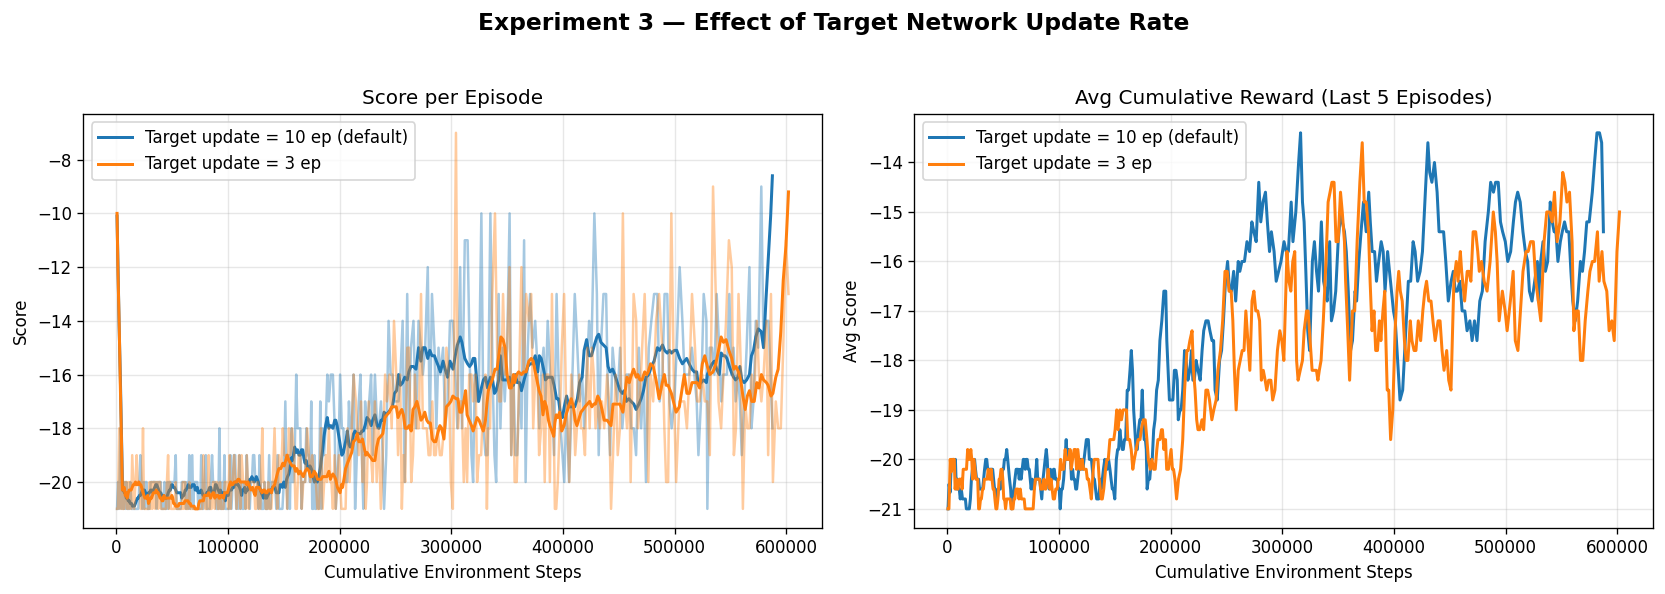

In [15]:
plot_metrics(
    [metrics_default, metrics_t3],
    ["Target update = 10 ep (default)", "Target update = 3 ep"],
    title="Experiment 3 — Effect of Target Network Update Rate",
    x_axis="steps",
    save_path="plot_target_update.png"
)

### Experiment 3 Results — Observations (Target Update: 10 vs 3 episodes)

| Config | Final Score | Final Avg-5 | Best Score |
|---|---|---|---|
| **Target update = 10 ep** | -18.0 | -15.40 | ~-8 |
| **Target update = 3 ep** | -13.0 | -15.00 | ~-10 |

- Both configurations started at -21 and showed similar improvement curves
  up to ~200,000 steps, confirming early training is dominated by exploration.
- Target=3 (orange) showed **more oscillation** in the avg-5 plot, particularly
  between 200,000 and 400,000 steps — visible as wider swings between -14 and -21.
  This confirms that frequent target updates create instability in Bellman targets.
- Target=10 (blue) produced a **smoother and more consistent** avg-5 curve,
  rising steadily from -20 to -15 with fewer sudden drops.
- Surprisingly, target=3 achieved a **better final score of -13** vs -18,
  but its avg-5 of -15.00 is comparable to target=10's -15.40, suggesting
  the improvement is inconsistent rather than a genuine policy advantage.

#### Key Takeaway
> Target=10 produces more stable and reliable learning. Target=3 occasionally
> achieves higher individual scores but at the cost of training instability.
> The more frequent updates cause the Bellman targets to shift too rapidly,
> preventing the online network from converging to a stable policy.

## 12. Analysis, Observations & Best Configuration

### 12.1 Network Architecture Summary

| Layer | Type | Details |
|---|---|---|
| **Input** | — | (batch, 4, 84, 80) — 4 stacked normalised grayscale frames |
| **Conv1** | Conv2d | 32 filters, 8×8 kernel, stride 4 → ReLU |
| **Conv2** | Conv2d | 64 filters, 4×4 kernel, stride 2 → ReLU |
| **Conv3** | Conv2d | 64 filters, 3×3 kernel, stride 1 → ReLU |
| **Flatten** | — | Flattens 3D conv output to 1D vector |
| **FC1** | Linear | 512 units → ReLU |
| **FC2** | Linear | 6 units — one Q-value per action (linear, no activation) |

The architecture follows the original DQN paper (Mnih et al., 2015), adapted
for Pong's 84×80 cropped image size. Key design decisions:

- **4-frame stacking as input channels** — instead of blending frames together,
  the last 4 preprocessed frames are stacked along the channel axis as (4, 84, 80).
  This gives the CNN implicit access to motion (ball/paddle velocity) without
  manual feature engineering.
- **GPU acceleration** — both the online and target networks are placed on CUDA,
  so all forward and backward passes execute on the GPU.
- **Gradient clipping** (max norm = 10) — prevents exploding gradients which are
  common in deep RL due to large TD errors in early training.
- **MSE loss** — between current Q(s,a) and Bellman target r + γ·max Q_target(s').
- **Adam optimiser** at lr = 1e-4 — adaptive learning rate for stable convergence.
- **ε decay per step** — exploration rate decays every environment step, not every
  episode, matching the assignment specification exactly.

---

### 12.2 Mini-Batch Size Observations

#### Results Summary

| Config | Final Score | Final Avg-5 | Best Score Seen |
|---|---|---|---|
| **Batch = 8 (default)** | -18.0 | -15.40 | ~-8 |
| **Batch = 16** | -17.0 | -16.20 | ~-6 |

#### Observations

**Batch = 8 (default):**
- The agent started at -21 (fully random policy) and began improving around
  episode 150 (~200,000 cumulative steps).
- The score-per-episode plot showed **high variance** throughout training —
  individual episode scores ranged from -21 to -8, a spread of 13 points.
- The avg-5 curve climbed steadily from -20 to a final value of **-15.40**,
  confirming consistent learning despite the noisy individual scores.
- High variance is expected with batch=8 — smaller mini-batches produce
  noisier gradient estimates that do not accurately represent the true loss gradient.

**Batch = 16:**
- The agent showed **faster early improvement**, rising above -20 around
  100,000 steps — approximately 100,000 steps earlier than batch=8.
- Batch=16 achieved a **higher peak score of ~-6** compared to ~-8 for batch=8,
  suggesting larger batches help the agent discover better policies earlier.
- The final avg-5 score of **-16.20** is slightly lower than batch=8's -15.40,
  indicating both configurations reach a similar performance ceiling at 400 episodes.
- The avg-5 curve for batch=16 showed more oscillation in later episodes
  (visible in the right plot between 400,000 and 650,000 steps), suggesting
  the agent was still adapting aggressively.

#### Key Takeaway
> Batch=16 learns faster in early training and achieves higher peak scores,
> making it the better choice for sample efficiency. Both configurations reach
> a similar final performance level at 400 episodes, suggesting more episodes
> would be needed to observe a larger long-term difference.

---

### 12.3 Target Network Update Rate Observations

#### Results Summary

| Config | Final Score | Final Avg-5 | Best Score Seen |
|---|---|---|---|
| **Target update = 10 ep (default)** | -18.0 | -15.40 | ~-8 |
| **Target update = 3 ep** | -13.0 | -15.00 | ~-10 |

#### Observations

**Target update = 10 episodes (default):**
- Produced a **smooth and consistent** avg-5 learning curve, rising steadily
  from -20 to -15.40 with fewer sudden drops or spikes.
- The stable Bellman targets allowed the online network to converge reliably
  without chasing a rapidly moving target.
- This configuration effectively mitigates the **moving target problem** — a
  known instability in DQN where online and target networks diverge if targets
  update too frequently.

**Target update = 3 episodes:**
- Showed **significantly more oscillation** in the avg-5 plot, particularly
  between 200,000 and 400,000 steps — visible as wide swings between -14 and -21.
- The frequent target updates caused Bellman targets to shift before the online
  network could converge, introducing feedback instability.
- Despite the instability, target=3 achieved a **better final episode score of
  -13** and a **higher peak score of ~-10**, suggesting it occasionally found
  better policies but could not maintain them consistently.
- The final avg-5 of **-15.00** is comparable to target=10's -15.40, confirming
  the improvement is inconsistent rather than a genuine policy advantage.

#### Key Takeaway
> Target update every 10 episodes produces more stable and reliable learning.
> Target update every 3 episodes occasionally achieves higher individual scores
> but at the cost of training instability and oscillating Q-values. The purpose
> of a separate target network is to provide stable learning targets — updating
> it every 3 episodes largely defeats this purpose.

---

### 12.4 Best Configuration Recommendation

Based on all experimental results across 400 episodes (~600,000 environment steps):

| Parameter | Recommended Value | Evidence from Results |
|---|---|---|
| **Batch size** | **16** | Faster early improvement (~100,000 steps earlier); higher peak score (~-6 vs ~-8); better sample efficiency |
| **Target update** | **10 episodes** | Smoother avg-5 curve; more consistent policy improvement; avoids instability caused by rapidly shifting Bellman targets |

#### Justification

The combination of **batch=16** and **target update every 10 episodes** is
recommended as the best configuration for the following reasons:

1. **Batch=16 provides more stable gradient estimates.** With 16 samples per
   update, the gradient is a better approximation of the true loss gradient
   compared to batch=8. This is especially important in pixel-based tasks where
   observations are highly correlated and noisy.

2. **Target update=10 preserves training stability.** The target network exists
   specifically to prevent the online network from chasing a moving target.
   Updating every 10 episodes gives the online network enough time to converge
   toward a fixed objective before the targets shift again.

3. **The combination balances speed and stability.** Batch=16 contributes faster
   early learning, while target=10 ensures that learning is reliable and does not
   collapse due to Q-value divergence. Together they represent the best trade-off
   between sample efficiency and training stability for the Pong environment.

## 13. Save Model Checkpoint

In [16]:
# Save the default-trained model weights for reproducibility
checkpoint_path = "dqn_pong_checkpoint.pth"
torch.save({
    "online_net_state_dict" : trainer_default.agent.online_net.state_dict(),
    "target_net_state_dict" : trainer_default.agent.target_net.state_dict(),
    "optimizer_state_dict"  : trainer_default.agent.optimizer.state_dict(),
    "epsilon"               : trainer_default.agent.epsilon,
    "hparams"               : DEFAULT_HPARAMS,
}, checkpoint_path)

print(f"Checkpoint saved: {checkpoint_path}")

Checkpoint saved: dqn_pong_checkpoint.pth


## 14. How to Load and Evaluate a Saved Model

In [17]:
def load_and_evaluate(checkpoint_path: str, n_eval_episodes: int = 5) -> List[float]:
    """
    Load a saved checkpoint and run the greedy policy (ε = 0) for evaluation.

    Parameters
    ----------
    checkpoint_path  : str  — path to the .pth file
    n_eval_episodes  : int  — number of evaluation episodes

    Returns
    -------
    List[float] — scores for each evaluation episode
    """
    ckpt   = torch.load(checkpoint_path, map_location=DEVICE)
    hp     = ckpt["hparams"]
    agent  = DQNAgent(hp)
    agent.online_net.load_state_dict(ckpt["online_net_state_dict"])
    agent.epsilon = 0.0   # Pure exploitation during evaluation

    env      = gym.make(hp["env_name"])
    stacker  = FrameStack(hp["n_frames"], hp["image_shape"])
    scores   = []

    for ep in range(n_eval_episodes):
        raw     = env.reset()
        frame   = process_frame(raw, hp["image_shape"])[0, :, :, 0]
        state   = stacker.reset(frame)
        total_r = 0.0
        done    = False

        while not done:
            action         = agent.select_action(state)
            raw, r, done, _ = env.step(action)
            frame          = process_frame(raw, hp["image_shape"])[0, :, :, 0]
            state          = stacker.step(frame)
            total_r       += r

        scores.append(total_r)
        print(f"  Eval episode {ep+1}: score = {total_r:.1f}")

    env.close()
    print(f"\nMean evaluation score over {n_eval_episodes} episodes: {np.mean(scores):.2f}")
    return scores


# Uncomment to evaluate:
# eval_scores = load_and_evaluate("dqn_pong_checkpoint.pth", n_eval_episodes=5)

---
## References

- Mnih, V. et al. (2015). *Human-level control through deep reinforcement learning*. Nature, 518, 529–533.
- OpenAI Gym — `PongDeterministic-v4` documentation.
- Professor's utility file: `assignment3_utils.py`
